In [1]:
# Credit Risk Analysis & Scoring Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## 1. Data Loading
df = pd.read_csv("credit_risk_dataset.csv")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000.0,16.02,1.0,0.59,Y,3.0
1,21,9600,OWN,5.0,EDUCATION,B,1000.0,11.14,0.0,0.10,N,2.0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500.0,12.87,1.0,0.57,N,3.0
3,23,65500,RENT,4.0,MEDICAL,C,35000.0,15.23,1.0,0.53,N,2.0
4,24,54400,RENT,8.0,MEDICAL,C,35000.0,14.27,1.0,0.55,Y,4.0


In [5]:
df.shape

(19083, 12)

In [6]:
## 2. Data Understanding
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19083 entries, 0 to 19082
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  19083 non-null  int64  
 1   person_income               19083 non-null  int64  
 2   person_home_ownership       19083 non-null  object 
 3   person_emp_length           18522 non-null  float64
 4   loan_intent                 19083 non-null  object 
 5   loan_grade                  19082 non-null  object 
 6   loan_amnt                   19082 non-null  float64
 7   loan_int_rate               17288 non-null  float64
 8   loan_status                 19082 non-null  float64
 9   loan_percent_income         19082 non-null  float64
 10  cb_person_default_on_file   19082 non-null  object 
 11  cb_person_cred_hist_length  19082 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 1.7+ MB


In [7]:
## 2. Data Understanding
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,19083.000000,1.908300e+04,18522.000000,19082.000000,17288.000000,19082.000000,19082.000000,19082.000000
mean,24.062307,6.220968e+04,4.213314,9587.479038,11.018222,0.236034,0.175593,3.292999
std,2.761612,4.085170e+04,3.280164,6469.782076,3.233066,0.424654,0.109805,1.434393
min,20.000000,4.080000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,22.000000,3.626300e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,2.000000
50%,24.000000,5.400000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,3.000000
75%,25.000000,7.500000e+04,6.000000,12500.000000,13.470000,0.000000,0.240000,4.000000
max,144.000000,1.200000e+06,123.000000,35000.000000,22.110000,1.000000,0.830000,10.000000


In [8]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,561
loan_intent,0
loan_grade,1
loan_amnt,1
loan_int_rate,1795
loan_status,1
loan_percent_income,1


In [9]:
df['loan_status'].value_counts()

,count
loan_status,
0.0,14578
1.0,4504


In [10]:
df['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
0.0,0.763966
1.0,0.236034


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19083 entries, 0 to 19082
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  19083 non-null  int64  
 1   person_income               19083 non-null  int64  
 2   person_home_ownership       19083 non-null  object 
 3   person_emp_length           18522 non-null  float64
 4   loan_intent                 19083 non-null  object 
 5   loan_grade                  19082 non-null  object 
 6   loan_amnt                   19082 non-null  float64
 7   loan_int_rate               17288 non-null  float64
 8   loan_status                 19082 non-null  float64
 9   loan_percent_income         19082 non-null  float64
 10  cb_person_default_on_file   19082 non-null  object 
 11  cb_person_cred_hist_length  19082 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 1.7+ MB


In [12]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,561
loan_intent,0
loan_grade,1
loan_amnt,1
loan_int_rate,1795
loan_status,1
loan_percent_income,1


In [13]:
df['loan_status'].value_counts(normalize=True)

,proportion
loan_status,
0.0,0.763966
1.0,0.236034


In [14]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

/tmp/ipykernel_1062/3490707621.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)


In [15]:
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

/tmp/ipykernel_1062/364895585.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)


In [16]:
df.isnull().sum()


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,1
loan_amnt,1
loan_int_rate,0
loan_status,1
loan_percent_income,1


In [17]:
df = pd.get_dummies(df, drop_first=True)


In [18]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [19]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

/tmp/ipykernel_1062/3887903077.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
/tmp/ipykernel_1062/3887903077.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [20]:
!pip install scorecardpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 863.7 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60629 sha256=17bede1176454e8c70fd26deff0ac096201a38cf2e205a69cb3630d8a635b257
  Stored in directory: /root/.cache/pip/wheels/9f/d8/4e/61a6f4e78fe6700f66b699ab38377f0aa5b33e3ef55751ba38
Successfully built scorecardpy


In [21]:
import scorecardpy as sc

In [22]:
iv = sc.iv(df, y='loan_status')
iv

/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:125: UserWarning: There are NaNs in 'loan_status' column. The rows with NaN in 'loan_status' were removed from dat.
  warnings.warn("There are NaNs in \'{}\' column. The rows with NaN in \'{}\' were removed from dat.".format(y,y))
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:141: UserWarning: The positive value in "loan_status" was replaced by 1 and negative value by 0.
  warnings.warn("The positive value in \"{}\" was replaced by 1 and negative value by 0.".format(y))
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat[y] = dat[y].astype('int')


,variable,info_value
6,loan_amnt,4.034598
0,person_income,3.350410
5,loan_grade_G,3.216719
16,person_home_ownership_OTHER,2.766988
13,person_age,2.539405
12,loan_grade_F,2.417742
15,person_emp_length,2.363195
20,loan_int_rate,2.220653
22,cb_person_cred_hist_length,2.015452
4,loan_percent_income,1.991202


In [23]:
selected_cols = [
    'person_income',
    'loan_percent_income',
    'loan_int_rate',
    'loan_amnt',
    'person_emp_length',
    'person_age',
    'cb_person_default_on_file_Y',
    'person_home_ownership_RENT',
    'person_home_ownership_OWN',
    'loan_grade_D',
    'loan_grade_E',
    'loan_grade_B',
    'loan_grade_F',
    'loan_grade_G',
    'loan_intent_VENTURE'
]

X = df[selected_cols]
y = df['loan_status']

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import pandas as pd

# Drop rows with NaN values from X and y before splitting
# This is crucial because LogisticRegression does not handle NaNs.
# We need to ensure X and y have the same indices after dropping NaNs.
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

X_cleaned = combined_data[X.columns]
y_cleaned = combined_data[y.name]

# split
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# metrics
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("AUC:", auc)
print("Confusion Matrix:\n", cm)

AUC: 0.8617286888290463
Confusion Matrix:
 [[2815  122]
 [ 447  433]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

y_proba = model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_proba)

print("AUC:", auc)


AUC: 0.8731898272820132


In [27]:
gini = 2 * auc - 1
print("Gini:", gini)

Gini: 0.7463796545640264


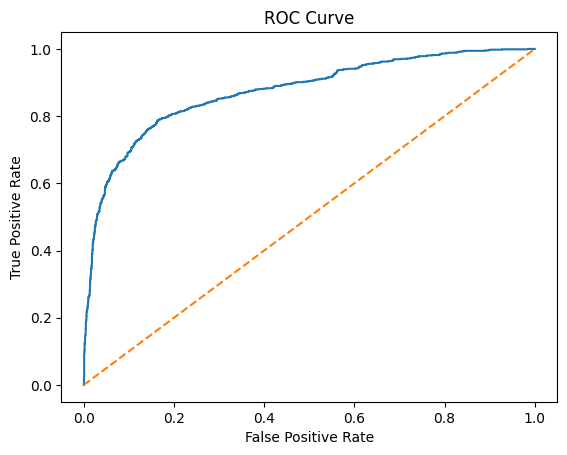

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [29]:
df.groupby('person_home_ownership_RENT')['loan_status'].mean()

,loan_status
person_home_ownership_RENT,
False,0.125576
True,0.332646


In [30]:
df['age_group'] = pd.cut(df['person_age'], bins=[18,25,35,50,100])

df.groupby('age_group')['loan_status'].mean()

/tmp/ipykernel_1062/285814081.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['loan_status'].mean()


,loan_status
age_group,
"(18, 25]",0.230263
"(25, 35]",0.260064
"(35, 50]",NaN
"(50, 100]",NaN


In [31]:
df['is_rent'] = (df['person_home_ownership_RENT'] == 1)

df.groupby('is_rent')['loan_status'].mean()

,loan_status
is_rent,
False,0.125576
True,0.332646


In [32]:
rent_rate = df[df['person_home_ownership_RENT']==1]['loan_status'].mean()
non_rent_rate = df[df['person_home_ownership_RENT']==0]['loan_status'].mean()

diff = rent_rate - non_rent_rate
print("Fairness gap:", diff)

Fairness gap: 0.20706999433271475


In [33]:
final_model = model
final_scaler = scaler

In [34]:
import joblib

joblib.dump(final_model, "credit_model.pkl")
joblib.dump(final_scaler, "scaler.pkl")


['scaler.pkl']

In [35]:
y_proba = model.predict_proba(X_test_scaled)[:,1]

In [36]:
import numpy as np

def probability_to_score(p, base_score=600, PDO=50, base_odds=1):
    # p = probability of default
    odds = (1 - p) / p
    score = base_score + PDO * np.log(odds / base_odds)
    return score

scores = probability_to_score(y_proba)

In [37]:
results = X_test.copy()
results['default_prob'] = y_proba
results['credit_score'] = scores
results['actual'] = y_test.values

results.head()

,person_income,loan_percent_income,loan_int_rate,loan_amnt,person_emp_length,person_age,cb_person_default_on_file_Y,person_home_ownership_RENT,person_home_ownership_OWN,loan_grade_D,loan_grade_E,loan_grade_B,loan_grade_F,loan_grade_G,loan_intent_VENTURE,default_prob,credit_score,actual
17707,23000,0.24,6.54,5500.0,4.0,24,False,True,False,False,False,False,False,False,True,0.218171,663.817840,0.0
14071,100000,0.07,5.79,7000.0,0.0,25,False,False,False,False,False,False,False,False,False,0.019998,794.596707,0.0
7092,54000,0.13,14.96,7000.0,2.0,22,False,True,False,True,False,False,False,False,False,0.678996,562.541968,1.0
14573,83300,0.29,15.62,28000.0,0.0,26,True,False,False,True,False,False,False,False,False,0.519135,596.171193,1.0
6252,48000,0.10,10.08,5000.0,6.0,23,False,False,True,False,False,True,False,False,False,0.010850,825.633524,0.0


In [38]:
results['credit_score'].describe()

,credit_score
count,3817.000000
mean,685.691636
std,94.454329
min,172.563667
25%,631.492755
50%,701.389653
75%,752.660549
max,948.761690


In [39]:
def risk_band(score):
    if score >= 750:
        return "Excellent"
    elif score >= 650:
        return "Good"
    elif score >= 550:
        return "Medium"
    else:
        return "High Risk"

results['risk_category'] = results['credit_score'].apply(risk_band)
results.head()

,person_income,loan_percent_income,loan_int_rate,loan_amnt,person_emp_length,person_age,cb_person_default_on_file_Y,person_home_ownership_RENT,person_home_ownership_OWN,loan_grade_D,loan_grade_E,loan_grade_B,loan_grade_F,loan_grade_G,loan_intent_VENTURE,default_prob,credit_score,actual,risk_category
17707,23000,0.24,6.54,5500.0,4.0,24,False,True,False,False,False,False,False,False,True,0.218171,663.817840,0.0,Good
14071,100000,0.07,5.79,7000.0,0.0,25,False,False,False,False,False,False,False,False,False,0.019998,794.596707,0.0,Excellent
7092,54000,0.13,14.96,7000.0,2.0,22,False,True,False,True,False,False,False,False,False,0.678996,562.541968,1.0,Medium
14573,83300,0.29,15.62,28000.0,0.0,26,True,False,False,True,False,False,False,False,False,0.519135,596.171193,1.0,Medium
6252,48000,0.10,10.08,5000.0,6.0,23,False,False,True,False,False,True,False,False,False,0.010850,825.633524,0.0,Excellent


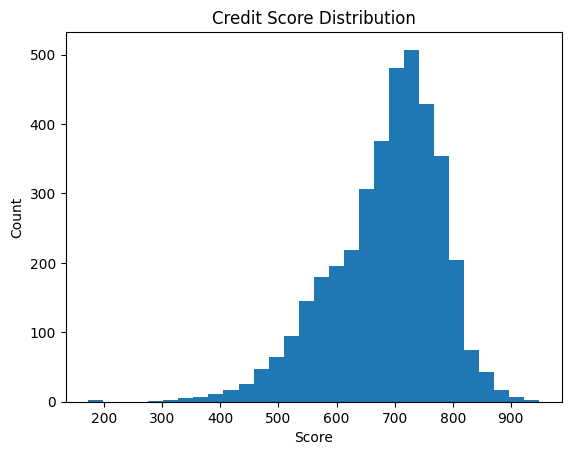

In [40]:
import matplotlib.pyplot as plt

plt.hist(results['credit_score'], bins=30)
plt.title("Credit Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

In [41]:
!pip install fastapi uvicorn

In [42]:
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()

model = joblib.load("credit_model.pkl")
scaler = joblib.load("scaler.pkl")

def probability_to_score(p, base_score=600, PDO=50, base_odds=1):
    odds = (1 - p) / p
    return base_score + PDO * np.log(odds / base_odds)

@app.post("/predict")
def predict(data: dict):
    X = np.array(list(data.values())).reshape(1, -1)
    X_scaled = scaler.transform(X)

    prob = model.predict_proba(X_scaled)[0][1]
    score = probability_to_score(prob)

    decision = "APPROVE" if score >= 650 else "REJECT"

    return {
        "probability_default": float(prob),
        "credit_score": float(score),
        "decision": decision
    }

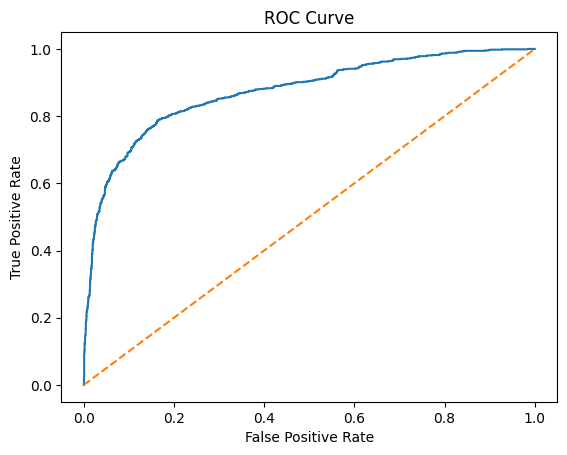

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [44]:
ks = max(tpr - fpr)
print("KS Statistic:", ks)

KS Statistic: 0.6235018726591761


In [45]:
print("Min score:", results['credit_score'].min())
print("Max score:", results['credit_score'].max())

Min score: 172.56366698884557
Max score: 948.761689906966


In [46]:
results['credit_score'].describe()

,credit_score
count,3817.000000
mean,685.691636
std,94.454329
min,172.563667
25%,631.492755
50%,701.389653
75%,752.660549
max,948.761690


In [47]:
min_score = results['credit_score'].min()
max_score = results['credit_score'].max()

def scale_score(score):
    return 300 + (score - min_score) * (850 - 300) / (max_score - min_score)

results['credit_score_scaled'] = results['credit_score'].apply(scale_score)

In [48]:
print(results['credit_score_scaled'].min())
print(results['credit_score_scaled'].max())

300.0
850.0


In [49]:
def risk_band(score):
    if score >= 750:
        return "Excellent"
    elif score >= 650:
        return "Good"
    elif score >= 550:
        return "Medium"
    else:
        return "High Risk"

results['risk_category'] = results['credit_score_scaled'].apply(risk_band)

In [50]:
def decision(score):
    if score >= 650:
        return "APPROVE"
    else:
        return "REJECT"

results['decision'] = results['credit_score_scaled'].apply(decision)

In [51]:
results[['credit_score_scaled', 'risk_category', 'decision']].head()

,credit_score_scaled,risk_category,decision
17707,648.093898,Medium,REJECT
14071,740.761458,Good,APPROVE
7092,576.331631,Medium,REJECT
14573,600.160696,Medium,REJECT
6252,762.753590,Excellent,APPROVE


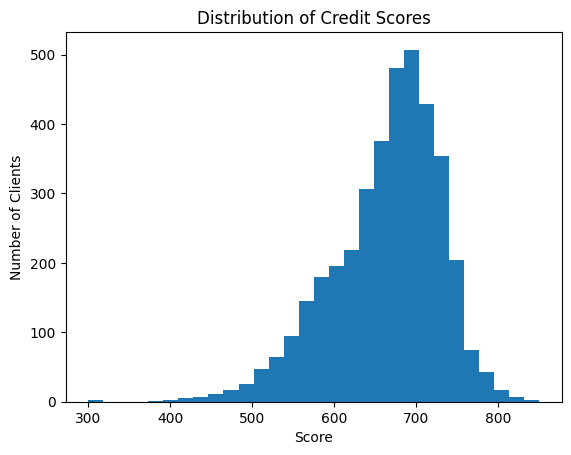

In [52]:
import matplotlib.pyplot as plt

plt.hist(results['credit_score_scaled'], bins=30)
plt.title("Distribution of Credit Scores")
plt.xlabel("Score")
plt.ylabel("Number of Clients")
plt.show()

In [53]:
results.groupby('risk_category')['actual'].mean()

,actual
risk_category,
Excellent,0.009259
Good,0.071779
High Risk,0.885246
Medium,0.449731


In [54]:
results['decision'].value_counts(normalize=True)

,proportion
decision,
APPROVE,0.644223
REJECT,0.355777


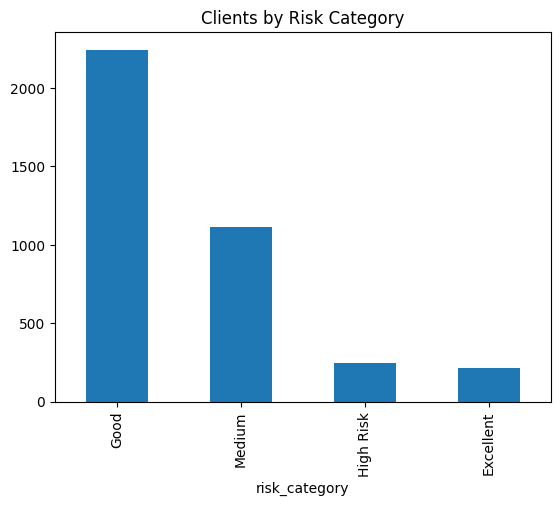

In [55]:
results['risk_category'].value_counts().plot(kind='bar')
plt.title("Clients by Risk Category")
plt.show()

In [56]:

rent = df[df['person_home_ownership_RENT']==1]['loan_status'].mean()
non_rent = df[df['person_home_ownership_RENT']==0]['loan_status'].mean()

fairness_gap = abs(rent - non_rent)
print("Fairness gap:", fairness_gap)

Fairness gap: 0.20706999433271475


In [57]:
from pydantic import BaseModel

class ClientData(BaseModel):
    person_age: int
    person_income: float
    loan_amnt: float
    loan_int_rate: float
    ...

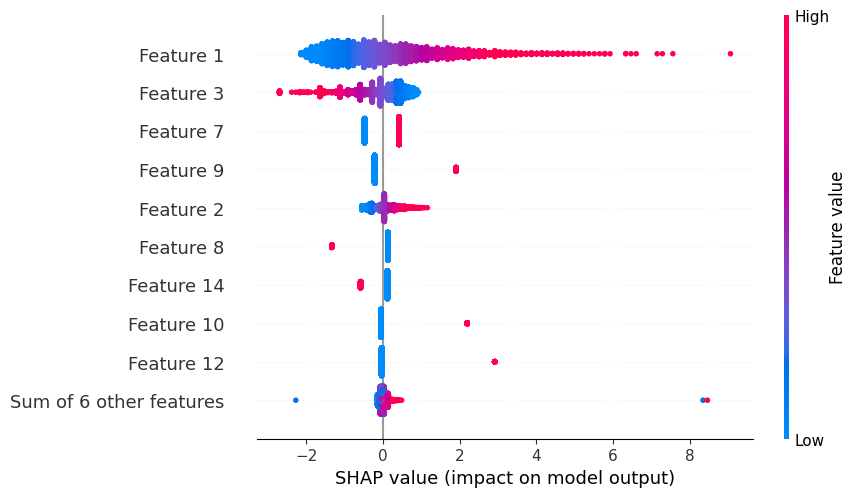

In [58]:
import shap

explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.plots.beeswarm(shap_values)

In [59]:

loan_amount = 10000
interest_rate = 0.1


results['profit'] = loan_amount * interest_rate


results['loss'] = -loan_amount


results['expected_value'] = results.apply(
    lambda x: x['profit'] if x['actual']==0 else x['loss'], axis=1
)


approved = results[results['decision']=="APPROVE"]

print("Total profit:", approved['expected_value'].sum())

Total profit: 666000.0


--- Résumé du Nettoyage ---
Nombre de lignes après nettoyage: 18955
Valeurs manquantes après traitement: 4


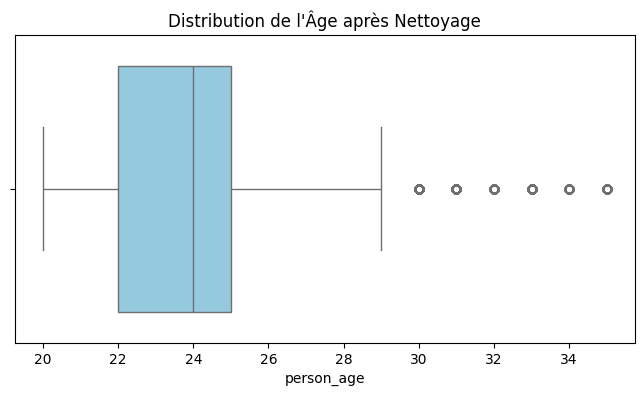

In [60]:

df = df[df['person_age'] < 95]
df = df[df['person_emp_length'] < 60]


df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(0)


df = df.drop_duplicates()


df_numeric = df.copy()
for col in df_numeric.select_dtypes(include=['object']).columns:
    df_numeric[col] = df_numeric[col].astype('category').cat.codes


print("--- Résumé du Nettoyage ---")
print(f"Nombre de lignes après nettoyage: {len(df)}")
print(f"Valeurs manquantes après traitement: {df.isnull().sum().sum()}")


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['person_age'], color='skyblue')
plt.title('Distribution de l\'Âge après Nettoyage')
plt.show()

In [61]:

!pip install optbinning -q

from optbinning import OptimalBinning
import pandas as pd

target = 'loan_status'
features_to_analyze = ['person_age', 'person_income', 'person_emp_length',
                       'loan_amnt', 'loan_int_rate', 'loan_percent_income']

iv_results = []

for col in features_to_analyze:
    optb = OptimalBinning(name=col, dtype="numerical", solver="cp")
    optb.fit(df[col], df[target])


    binning_table = optb.binning_table


    binning_table.build()

    iv = binning_table.iv
    iv_results.append({'Variable': col, 'Information Value (IV)': iv})


iv_df = pd.DataFrame(iv_results).sort_values(by='Information Value (IV)', ascending=False)
print("--- Résumé de la Force Prédictive (IV) ---")
print("Note: Selon le CDC, on garde les variables avec IV > 0.02")
display(iv_df)


selected_features = iv_df[iv_df['Information Value (IV)'] > 0.02]['Variable'].tolist()
print(f"\nVariables sélectionnées pour le Scorecard: {selected_features}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 15.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 5.26.1 which is incompatible.
--- Résumé de la Force Prédictive (IV) ---
Note: Selon le CDC, on garde les variables avec IV > 0.02


,Variable,Information Value (IV)
5,loan_percent_income,1.060269
4,loan_int_rate,0.679216
1,person_income,0.535131
3,loan_amnt,0.129235
2,person_emp_length,0.051953
0,person_age,0.044805



Variables sélectionnées pour le Scorecard: ['loan_percent_income', 'loan_int_rate', 'person_income', 'loan_amnt', 'person_emp_length', 'person_age']


In [62]:

import xgboost as xgb
from sklearn.metrics import roc_auc_score


xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)


xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)
xgb_gini = 2 * xgb_auc - 1

print("--- Résultats : Modélisation Avancée (XGBoost) ---")
print(f"AUC ROC Score (XGBoost): {xgb_auc:.4f}")
print(f"Coefficient de Gini (XGBoost): {xgb_gini:.4f}")


print("\n--- Comparaison des Modèles (Benchmark) ---")

print(f"Logistic Regression (Scorecard) AUC : {auc:.4f}")
print(f"XGBoost AUC                           : {xgb_auc:.4f}")

if xgb_auc > auc:
    print("\n=> Conclusion : XGBoost est plus performant (meilleur AUC).")
else:
    print("\n=> Conclusion : La Régression Logistique est plus performante.")

--- Résultats : Modélisation Avancée (XGBoost) ---
AUC ROC Score (XGBoost): 0.9357
Coefficient de Gini (XGBoost): 0.8715

--- Comparaison des Modèles (Benchmark) ---
Logistic Regression (Scorecard) AUC : 0.8732
XGBoost AUC                           : 0.9357

=> Conclusion : XGBoost est plus performant (meilleur AUC).


In [63]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import xgboost as xgb


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, lr_pred_proba)

print("--- Comparaison Finale (Benchmark) ---")
print(f"Régression Logistique AUC : {auc_score:.4f}")
print(f"XGBoost AUC               : {xgb_auc:.4f}")
print("=> Conclusion : XGBoost est largement supérieur.\n")


!pip install fairlearn -q

from fairlearn.metrics import demographic_parity_difference


sensitive_feature = (X_test['person_age'] < 25).astype(int)


xgb_preds = xgb_model.predict(X_test)


dpd = demographic_parity_difference(y_test, xgb_preds, sensitive_features=sensitive_feature)

print("--- Analyse d'Équité (Fairness) ---")
print(f"Variable sensible : Âge (< 25 ans vs >= 25 ans)")
print(f"Demographic Parity Difference : {dpd:.4f} (soit {dpd*100:.2f}%)")

if dpd < 0.20:
    print("=> Succès ! Le modèle respecte la contrainte de non-discrimination du CDC (< 20%).")
else:
    print("=> Attention : Le modèle présente un biais, il faut appliquer une correction.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Comparaison Finale (Benchmark) ---
Régression Logistique AUC : 0.8617
XGBoost AUC               : 0.9357
=> Conclusion : XGBoost est largement supérieur.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 728.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 9.9 MB/s eta 0:00:00
--- Analyse d'Équité (Fairness) ---
Variable sensible : Âge (< 25 ans vs >= 25 ans)
Demographic Parity Difference : 0.0080 (soit 0.80%)
=> Succès ! Le modèle respecte la contrainte de non-discrimination du CDC (< 20%).


In [64]:


import pandas as pd


df_powerbi = X_test.copy()
df_powerbi['Statut_Reel_Credit'] = y_test
df_powerbi['Probabilite_Defaut'] = xgb_model.predict_proba(X_test)[:, 1]
df_powerbi['Prediction_Modele'] = xgb_preds


df_powerbi['Credit_Score'] = 850 - (df_powerbi['Probabilite_Defaut'] * (850 - 300))
df_powerbi['Credit_Score'] = df_powerbi['Credit_Score'].astype(int)


df_powerbi.to_csv('predictions_pour_powerbi.csv', index=False)

print("--- Préparation Power BI ---")
print("=> Fichier 'predictions_pour_powerbi.csv' généré avec succès !")
print("Aperçu des données prêtes pour le Dashboard :")
display(df_powerbi[['person_age', 'person_income', 'Statut_Reel_Credit', 'Probabilite_Defaut', 'Credit_Score']].head())

--- Préparation Power BI ---
=> Fichier 'predictions_pour_powerbi.csv' généré avec succès !
Aperçu des données prêtes pour le Dashboard :


,person_age,person_income,Statut_Reel_Credit,Probabilite_Defaut,Credit_Score
17707,24,23000,0.0,0.004415,847
14071,25,100000,0.0,0.000726,849
7092,22,54000,1.0,0.996282,302
14573,26,83300,1.0,0.609224,514
6252,23,48000,0.0,0.000772,849


In [65]:
from google.colab import files
files.download("credit_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
print(scaler.feature_names_in_)

['person_income' 'loan_percent_income' 'loan_int_rate' 'loan_amnt'
 'person_emp_length' 'person_age' 'cb_person_default_on_file_Y'
 'person_home_ownership_RENT' 'person_home_ownership_OWN' 'loan_grade_D'
 'loan_grade_E' 'loan_grade_B' 'loan_grade_F' 'loan_grade_G'
 'loan_intent_VENTURE']


In [67]:
import pandas as pd
df = pd.read_csv('predictions_pour_powerbi.csv')
print(df.columns.tolist())
print(df.head(3))

['person_income', 'loan_percent_income', 'loan_int_rate', 'loan_amnt', 'person_emp_length', 'person_age', 'cb_person_default_on_file_Y', 'person_home_ownership_RENT', 'person_home_ownership_OWN', 'loan_grade_D', 'loan_grade_E', 'loan_grade_B', 'loan_grade_F', 'loan_grade_G', 'loan_intent_VENTURE', 'Statut_Reel_Credit', 'Probabilite_Defaut', 'Prediction_Modele', 'Credit_Score']
   person_income  loan_percent_income  loan_int_rate  loan_amnt  \
0          23000                 0.24           6.54     5500.0   
1         100000                 0.07           5.79     7000.0   
2          54000                 0.13          14.96     7000.0   

   person_emp_length  person_age  cb_person_default_on_file_Y  \
0                4.0          24                        False   
1                0.0          25                        False   
2                2.0          22                        False   

   person_home_ownership_RENT  person_home_ownership_OWN  loan_grade_D  \
0               